In [92]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

import os
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage,HumanMessage

import psycopg
from psycopg.rows import dict_row
from psycopg_pool import ConnectionPool
from langgraph.checkpoint.postgres import PostgresSaver
from dotenv import load_dotenv

load_dotenv()



True

In [93]:
def get_database_url():
    database_url = os.getenv("DATABASE_URL")

    if not database_url:
        raise ValueError("DATABASE_URL is missing. Please add your Render PostgreSQL External Database URL to .env")
    if "sslmode=" not in database_url:
        separator = "&" if "?" in database_url else "?"
        database_url += f"{separator}sslmode=require"
    return database_url

In [94]:
url = get_database_url()


In [95]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY is missing. Please add your GROQ API key to .env")

In [96]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="what to cover")


In [97]:
class Plan(BaseModel):
    blog_title: str
    tasks: list[Task]

In [118]:
class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str], operator.add]
    final: str

In [129]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key = GROQ_API_KEY
)

In [119]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content="Create a blog plan with 5-7 sections on the following topic."
            ),
            HumanMessage(
                content=f"Topic: {state['topic']}"
            ),
        ]
    )
    return {"plan":plan}
                
        

In [120]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"],"plan":state["plan"]}) 
            for task in state["plan"].tasks]

In [121]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_content = llm.invoke(
        [
            SystemMessage(
                content="Write a blog section based on the following brief."
            ),
            HumanMessage(
                content=(
                    f"Blog Title: {blog_title}\n"
                    f"Topic: {topic}\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}"
                )
            )
        ]
    )

    return {
        "sections": [section_content.content]
    }

In [110]:
def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    filename_md = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename_md)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [122]:
g = StateGraph(State)

g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

In [113]:
DATABASE_URL = get_database_url()

pool = ConnectionPool(
    conninfo=DATABASE_URL,
    min_size=1,
    max_size=5,
    kwargs={"autocommit": True, "prepare_threshold": 0},
)

checkpointer = PostgresSaver(pool)
checkpointer.setup()
app = g.compile(checkpointer=checkpointer)


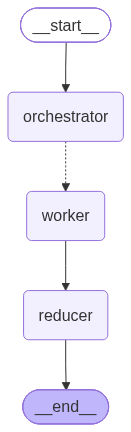

In [123]:
app = g.compile(checkpointer=checkpointer)
app

In [124]:
config = {
    "configurable": {
        "thread_id": "test_thread_id"
    }
}

In [135]:
import time

config = {
    "configurable": {
        "thread_id": "blog-2"
    }
}

max_retries = 4
delay = 10

for attempt in range(1, max_retries + 1):
    try:
        out = app.invoke(
            {
                "topic": "Write a blog on generative AI and its impact on the future of work",
                "sections": []
            },
            config=config
        )
        break
    except Exception as e:
        msg = str(e).lower()
        if "rate limit" in msg or "429" in msg:
            print(f"Rate limit hit on attempt {attempt}/{max_retries}. Retrying in {delay}s...")
            time.sleep(delay)
            delay *= 2

            # switch to a model with a higher quota if available
            if getattr(llm, "model_name", None) != "llama-3.3-70b-versatile":
                llm = ChatGroq(
                    model="llama-3.3-70b-versatile",
                    api_key=GROQ_API_KEY
                )
            if attempt == max_retries:
                raise
            continue

        raise

print(out)

{'topic': 'Write a blog on generative AI and its impact on the future of work', 'plan': Plan(blog_title='Generative AI and Its Impact on the Future of Work', tasks=[Task(id=1, title='Introduction: What Is Generative AI?', brief='Define generative AI, explain its core technologies like GPT, diffusion models, and how they differ from traditional AI.'), Task(id=2, title='The Upside: Boosting Productivity and Creativity', brief='Explore how generative AI automates routine tasks, generates ideas, and enables rapid prototyping across industries.'), Task(id=3, title='Redefining Skill Sets: From Manual to Strategic', brief='Discuss the shift from repetitive jobs to higher-level roles, the rise of AI fluency, and the need for continuous learning.'), Task(id=4, title='Ethical, Legal, and Social Considerations', brief='Address concerns about bias, ownership of AI-generated content, job displacement, and the role of policy.'), Task(id=5, title='Case Studies: Generative AI in Action', brief='Provid

In [136]:
# Get generated sections
sections = out.get("sections", [])

print("Number of sections:", len(sections))

# Create the blog content
blog_content = f"# {out['topic']}\n\n"

for section in sections:
    blog_content += str(section) + "\n\n"

# Save the blog
with open("demystifying_self-attention.md", "w", encoding="utf-8") as file:
    file.write(blog_content)

print("✅ Blog saved successfully!")
print("File contains:", len(blog_content), "characters")

Number of sections: 31
✅ Blog saved successfully!
File contains: 164936 characters
